<a href="https://colab.research.google.com/github/Krishnamurthy4224/Phase2/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("customer_support_tickets.csv")
df.head(50)

Saving customer_support_tickets.csv to customer_support_tickets (1).csv


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


In [ ]:
import re

df = pd.read_csv('customer_support_tickets.csv')

df.drop_duplicates(inplace=True)

df.dropna(subset=['Ticket Subject', 'Ticket Description', 'Resolution'], inplace=True)

df['combined_text'] = df['Ticket Subject'].astype(str) + " " + df['Ticket Description'].astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['combined_text'].apply(clean_text)
df['cleaned_response'] = df['Resolution'].astype(str).apply(clean_text)

df = df[df['cleaned_text'].str.len() > 10]
df = df[df['cleaned_response'].str.len() > 5]

df[['cleaned_text', 'cleaned_response']].to_csv('/content/cleaned_customer_support_tickets.csv', index=False)

print("Data cleaning completed and saved as 'cleaned_customer_support_tickets.csv'")

Data cleaning completed and saved as 'cleaned_customer_support_tickets.csv'


Top 10 most common query words:
[('the', 8748), ('productpurchased', 4583), ('issue', 4257), ('to', 3572), ('im', 3424), ('my', 3071), ('please', 2936), ('with', 2750), ('it', 2423), ('an', 2421)]


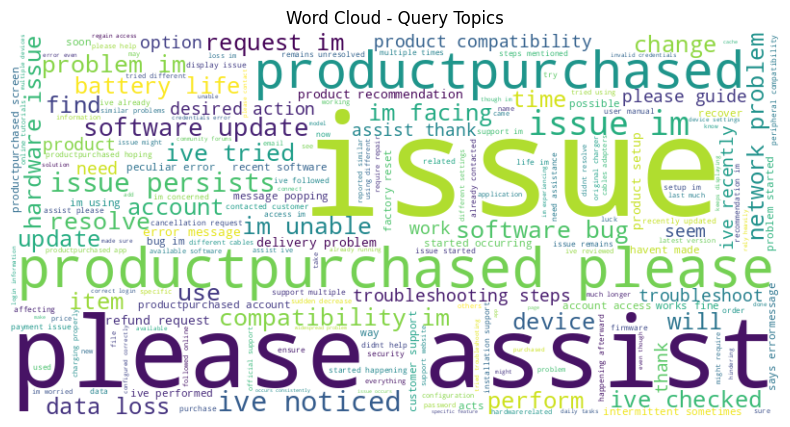

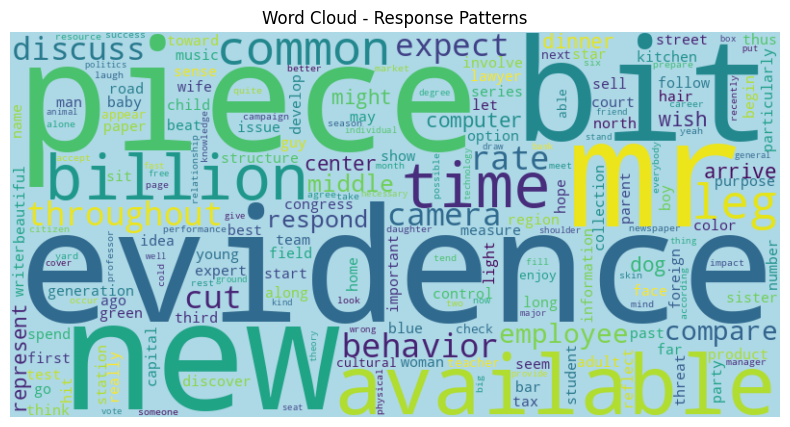

<ipython-input-7-ee270ba2f1bc>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=query_df, x='word', y='count', palette='magma')


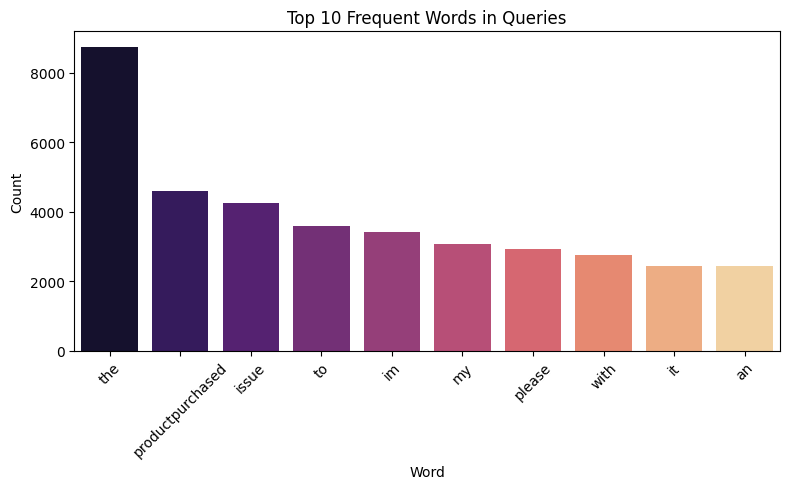

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns

df = pd.read_csv('/content/cleaned_customer_support_tickets.csv')  # Make sure the path is correct

all_query_words = ' '.join(df['cleaned_text'].dropna())
query_word_freq = Counter(all_query_words.split())

print("Top 10 most common query words:")
print(query_word_freq.most_common(10))

plt.figure(figsize=(10, 5))
query_wc = WordCloud(width=800, height=400, background_color='white').generate(all_query_words)
plt.imshow(query_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Query Topics')
plt.show()

all_response_words = ' '.join(df['cleaned_response'].dropna())
response_wc = WordCloud(width=800, height=400, background_color='lightblue').generate(all_response_words)
plt.figure(figsize=(10, 5))
plt.imshow(response_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Response Patterns')
plt.show()

query_df = pd.DataFrame(query_word_freq.most_common(10), columns=['word', 'count'])
plt.figure(figsize=(8, 5))
sns.barplot(data=query_df, x='word', y='count', palette='magma')
plt.title('Top 10 Frequent Words in Queries')
plt.ylabel('Count')
plt.xlabel('Word')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

import pandas as pd
from sentence_transformers import SentenceTransformer
import torch

df = pd.read_csv('/content/cleaned_customer_support_tickets.csv')

model = SentenceTransformer('all-MiniLM-L6-v2')  # Pre-trained, sentence-level BERT

texts = df['cleaned_text'].astype(str).tolist()

embeddings = model.encode(texts, show_progress_bar=True)

embeddings_df = pd.DataFrame(embeddings)

final_df = pd.concat([embeddings_df, df['cleaned_response'].reset_index(drop=True)], axis=1)

final_df.to_csv('/content/bert_embeddings_with_responses.csv', index=False)

print("BERT embeddings created and saved as 'bert_embeddings_with_responses.csv'")

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

BERT embeddings created and saved as 'bert_embeddings_with_responses.csv'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

df = pd.read_csv('/content/cleaned_customer_support_tickets.csv')
df.columns = df.columns.str.strip()  # remove extra spaces

print("Columns:", df.columns.tolist())

df = df[['cleaned_text', 'cleaned_response']].dropna()
df['intent'] = df['cleaned_text'].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "general")

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("SVM Report:")
print(classification_report(y_test, svm_pred))
print("Random Forest Report:")
print(classification_report(y_test, rf_pred))

def get_response(user_query):
    query_vec = vectorizer.transform([user_query])
    similarity = cosine_similarity(query_vec, X)
    best_match = np.argmax(similarity)
    return df.iloc[best_match]['cleaned_response']

query = "issue with product setup"
print("\nUser Query:", query)
print("Chatbot Response:", get_response(query))

Columns: ['cleaned_text', 'cleaned_response']
SVM Report:
              precision    recall  f1-score   support

     account       0.83      0.96      0.89        25
     battery       0.93      0.96      0.95        28
cancellation       1.00      1.00      1.00        28
        data       0.97      0.97      0.97        34
    delivery       1.00      0.97      0.98        30
     display       1.00      1.00      1.00        35
    hardware       0.97      0.87      0.92        38
installation       1.00      1.00      1.00        24
     network       0.91      1.00      0.95        39
     payment       0.97      1.00      0.98        30
  peripheral       1.00      1.00      1.00        31
     product       0.99      0.98      0.98       128
      refund       1.00      0.93      0.97        45
    software       0.95      0.95      0.95        39

    accuracy                           0.97       554
   macro avg       0.97      0.97      0.97       554
weighted avg       0.9


SVM Evaluation:
Accuracy: 0.9693140794223827
Precision: 0.9711722954922933
Recall: 0.9693140794223827
F1 Score: 0.9695156720148956


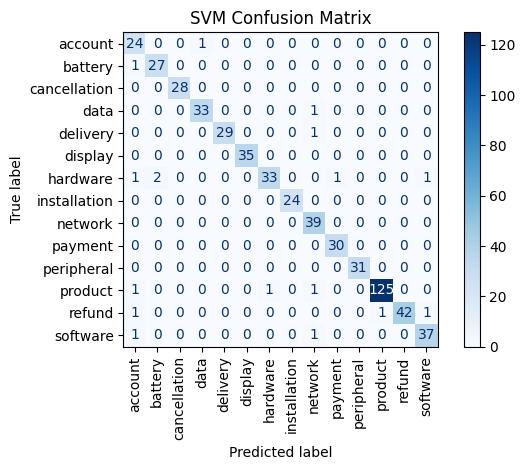


Random Forest Evaluation:
Accuracy: 0.9891696750902527
Precision: 0.9898563028760841
Recall: 0.9891696750902527
F1 Score: 0.9893237778230731


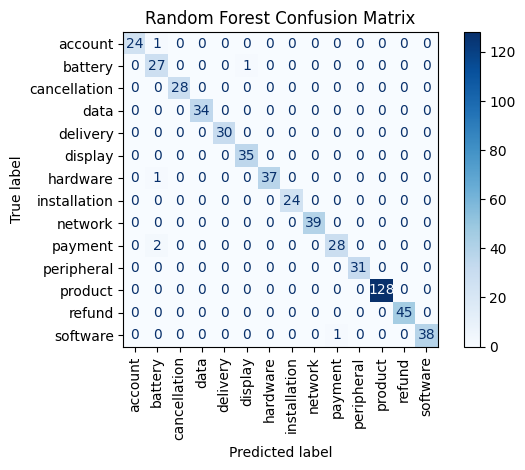

In [ ]:
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm_pred = svm.predict(X_test)
rf_pred = rf.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average='weighted', zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted', zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot(xticks_rotation=90, cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

evaluate_model("SVM", y_test, svm_pred)

evaluate_model("Random Forest", y_test, rf_pred)

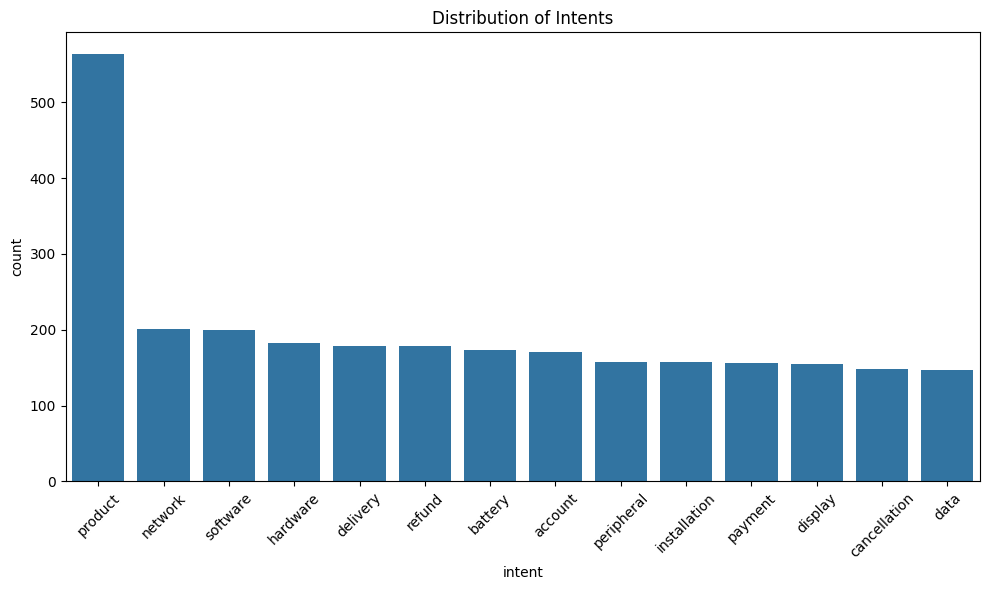

<ipython-input-14-cd351879266e>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics, palette='pastel')


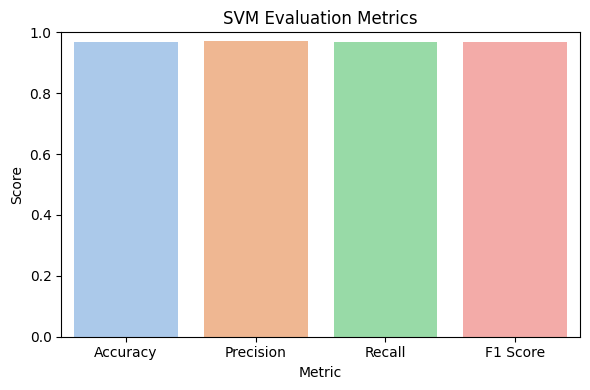

<ipython-input-14-cd351879266e>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics, palette='pastel')


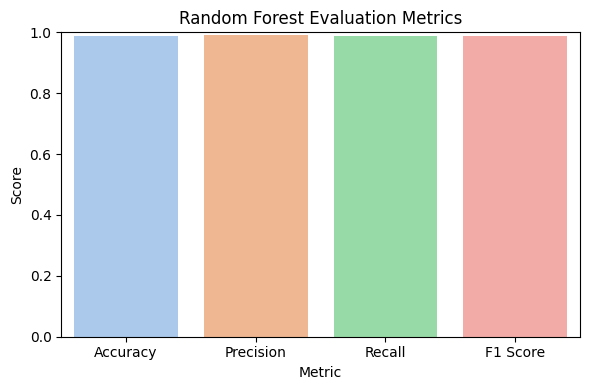

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
<ipython-input-14-cd351879266e>:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words, palette='mako')


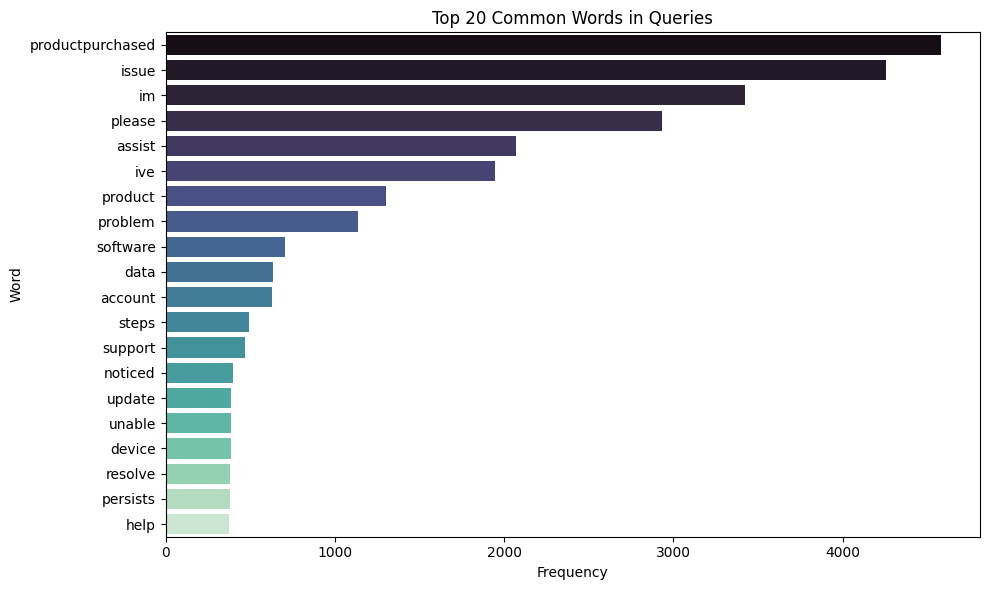

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load cleaned dataset
df = pd.read_csv('/content/cleaned_customer_support_tickets.csv')
df.columns = df.columns.str.strip()

# Assume 'intent' column is already created (if not, create dummy intent)
if 'intent' not in df.columns:
    df['intent'] = df['cleaned_text'].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "general")

# 1. Intent Distribution Plot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='intent', order=df['intent'].value_counts().index)
plt.title('Distribution of Intents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Chatbot Accuracy Report (using stored predictions)
def plot_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    metrics = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Score': [accuracy, precision, recall, f1]
    })

    plt.figure(figsize=(6,4))
    sns.barplot(x='Metric', y='Score', data=metrics, palette='pastel')
    plt.ylim(0, 1)
    plt.title(f'{model_name} Evaluation Metrics')
    plt.tight_layout()
    plt.show()

# Run for SVM
plot_metrics(y_test, svm_pred, "SVM")

# Run for Random Forest
plot_metrics(y_test, rf_pred, "Random Forest")

# 3. EDA Findings: Most Common Words (Word Cloud optional if wordcloud installed)
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Get word frequency
words = ' '.join(df['cleaned_text']).lower().split()
words = [word for word in words if word not in stop_words]
word_freq = Counter(words)

# Top 20 words
common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Word', data=common_words, palette='mako')
plt.title("Top 20 Common Words in Queries")
plt.tight_layout()
plt.show()